33831.14062981048
0.9805066879118973


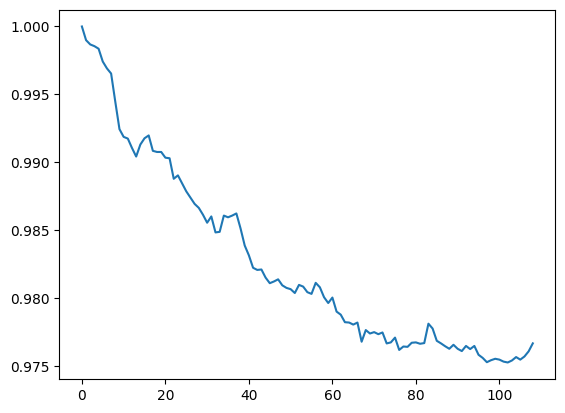

In [16]:
# LLaDA flash -> jump step 1
import ast
data1 = []
with open("out/main-16516150.out", "r") as f:
    for line in f:
        if line.startswith("{"):
            record = ast.literal_eval(line)
            if "offload_stats" in record:
                data1.append(record)
steps = len(data1)
demotions = sum([i["offload_stats"]["demotions"] for i in data1])
promotions = sum([i["offload_stats"]["promotions"] for i in data1])
cpu_tokens = sum([i["offload_stats"]["cpu_tokens"] for i in data1])
gpu_tokens = sum([i["offload_stats"]["gpu_tokens"] for i in data1])
elapsed_ms = sum([i["elapsed_ms"] for i in data1])
print(elapsed_ms / steps)
print(gpu_tokens / (gpu_tokens + cpu_tokens))
from matplotlib import pyplot as plt
plt.plot([(i["offload_stats"]["gpu_tokens"] / (i["offload_stats"]["gpu_tokens"] + i["offload_stats"]["cpu_tokens"])) for i in data1])

48033.30545596974
0.9775582479383944


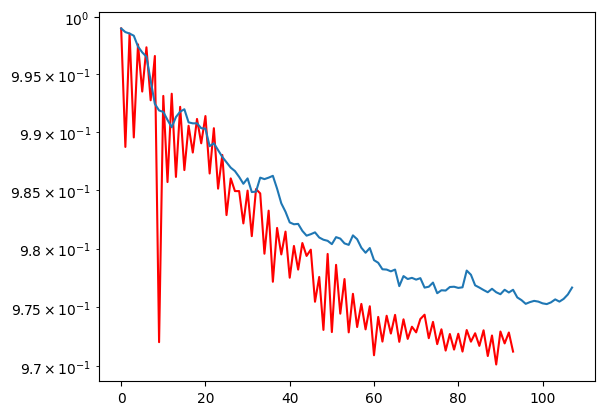

In [41]:
# LLaDA flash -> jump step 2
import ast
data = []
with open("out/main-16608064.out", "r") as f:
    for line in f:
        if line.startswith("{"):
            record = ast.literal_eval(line)
            if "offload_stats" in record:
                data.append(record)
steps = len(data)
demotions = sum([i["offload_stats"]["demotions"] for i in data])
promotions = sum([i["offload_stats"]["promotions"] for i in data])
cpu_tokens = sum([i["offload_stats"]["cpu_tokens"] for i in data])
gpu_tokens = sum([i["offload_stats"]["gpu_tokens"] for i in data])
elapsed_ms = sum([i["elapsed_ms"] for i in data])
print(elapsed_ms / steps)
print(gpu_tokens / (gpu_tokens + cpu_tokens))
from matplotlib import pyplot as plt
plt.plot([(i["offload_stats"]["gpu_tokens"] / (i["offload_stats"]["gpu_tokens"] + i["offload_stats"]["cpu_tokens"])) for i in data[1:]], color="red")
from matplotlib import pyplot as plt
plt.plot([(i["offload_stats"]["gpu_tokens"] / (i["offload_stats"]["gpu_tokens"] + i["offload_stats"]["cpu_tokens"])) for i in data1[1:]])
plt.yscale("log")

In [3]:
# JIT -> 5 step
import ast
data = []
with open("out/eval_dinfer-16613746.out", "r") as f:
    for line in f:
        if line.startswith("{"):
            record = ast.literal_eval(line)
            if "offload_stats" in record:
                data.append(record)
steps = len(data)
demotions = sum([i["offload_stats"]["demotions"] for i in data])
promotions = sum([i["offload_stats"]["promotions"] for i in data])
cpu_tokens = sum([i["offload_stats"]["cpu_tokens"] for i in data])
gpu_tokens = sum([i["offload_stats"]["gpu_tokens"] for i in data])
elapsed_ms = sum([i["elapsed_ms"] for i in data])
print(elapsed_ms / steps)
sum([i["transferred_tokens"] for i in data])

2301.046171326501


1712

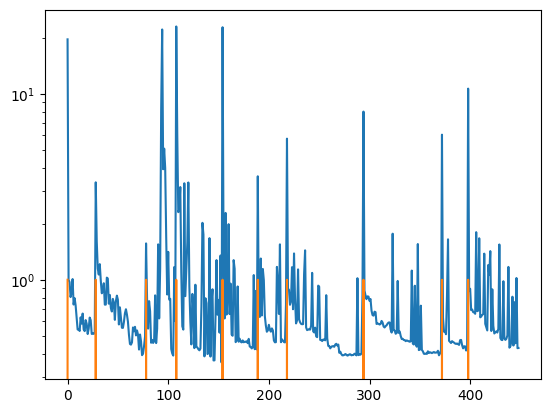

In [31]:
# JIT -> 1 step
import ast
data = []
with open("out/eval_dinfer-16484569.out", "r") as f:
    for line in f:
        if line.startswith("{"):
            record = ast.literal_eval(line)
            if "offload_stats" in record:
                data.append(record)
steps = len(data)
demotions = sum([i["offload_stats"]["demotions"] for i in data])
promotions = sum([i["offload_stats"]["promotions"] for i in data])
cpu_tokens = sum([i["offload_stats"]["cpu_tokens"] for i in data])
gpu_tokens = sum([i["offload_stats"]["gpu_tokens"] for i in data])
elapsed_ms = sum([i["elapsed_ms"] for i in data])

ratios1 = {}
for step in data:
    ratio = step["offload_stats"]["gpu_tokens"] / (step["offload_stats"]["gpu_tokens"] + step["offload_stats"]["cpu_tokens"])
    if step["block"] not in ratios1:
        ratios1[step["block"]] = []
    ratios1[step["block"]].append(ratio)

# compute mean ratio for each block (blocks sorted by number)
blocks1 = sorted(ratios1.keys())
avg_ratios1 = [sum(ratios1[b]) / len(ratios1[b]) for b in blocks1]
plt.plot([(i["elapsed_ms"] / i["offload_stats"]["cpu_tokens"]) for i in data])
is_start = []
for i in range(len(data)):
    if i == 0 or data[i]["block"] < data[i-1]["block"]:
        is_start.append(1)
    else:
        is_start.append(0)
plt.plot(is_start)
plt.yscale("log")

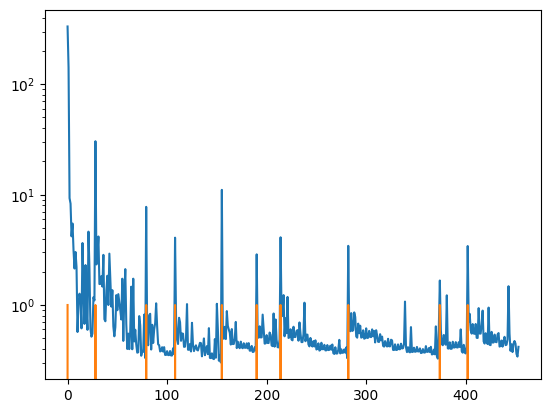

In [35]:
# JIT -> 3 step
import ast
data = []
with open("out/eval_dinfer-16516407.out", "r") as f:
    for line in f:
        if line.startswith("{"):
            record = ast.literal_eval(line)
            if "offload_stats" in record:
                data.append(record)
steps = len(data)
demotions = sum([i["offload_stats"]["demotions"] for i in data])
promotions = sum([i["offload_stats"]["promotions"] for i in data])
cpu_tokens = sum([i["offload_stats"]["cpu_tokens"] for i in data])
gpu_tokens = sum([i["offload_stats"]["gpu_tokens"] for i in data])
elapsed_ms = sum([i["elapsed_ms"] for i in data])

ratios3 = {}
for step in data:
    ratio = step["offload_stats"]["gpu_tokens"] / (step["offload_stats"]["gpu_tokens"] + step["offload_stats"]["cpu_tokens"])
    if step["block"] not in ratios3:
        ratios3[step["block"]] = []
    ratios3[step["block"]].append(ratio)

# compute mean ratio for each block (blocks sorted by number)
blocks3 = sorted(ratios3.keys())
avg_ratios3 = [sum(ratios3[b]) / len(ratios3[b]) for b in blocks3]
plt.plot([(i["elapsed_ms"] / i["offload_stats"]["cpu_tokens"]) for i in data])
is_start = []
for i in range(len(data)):
    if i == 0 or data[i]["block"] < data[i-1]["block"]:
        is_start.append(1)
    else:
        is_start.append(0)
plt.plot(is_start)
plt.yscale("log")

In [6]:
# JIT -> 4 step
import ast
data = []
with open("out/eval_dinfer-16516409.out", "r") as f:
    for line in f:
        if line.startswith("{"):
            record = ast.literal_eval(line)
            if "offload_stats" in record:
                data.append(record)
steps = len(data)
demotions = sum([i["offload_stats"]["demotions"] for i in data])
promotions = sum([i["offload_stats"]["promotions"] for i in data])
cpu_tokens = sum([i["offload_stats"]["cpu_tokens"] for i in data])
gpu_tokens = sum([i["offload_stats"]["gpu_tokens"] for i in data])
elapsed_ms = sum([i["elapsed_ms"] for i in data])

ratios4 = {}
for step in data:
    ratio = step["offload_stats"]["gpu_tokens"] / (step["offload_stats"]["gpu_tokens"] + step["offload_stats"]["cpu_tokens"])
    if step["block"] not in ratios4:
        ratios4[step["block"]] = []
    ratios4[step["block"]].append(ratio)

# compute mean ratio for each block (blocks sorted by number)
blocks4 = sorted(ratios4.keys())
avg_ratios4 = [sum(ratios4[b]) / len(ratios4[b]) for b in blocks4]

In [7]:
# JIT -> 5 step
import ast
data = []
with open("out/eval_dinfer-16516410.out", "r") as f:
    for line in f:
        if line.startswith("{"):
            record = ast.literal_eval(line)
            if "offload_stats" in record:
                data.append(record)
steps = len(data)
demotions = sum([i["offload_stats"]["demotions"] for i in data])
promotions = sum([i["offload_stats"]["promotions"] for i in data])
cpu_tokens = sum([i["offload_stats"]["cpu_tokens"] for i in data])
gpu_tokens = sum([i["offload_stats"]["gpu_tokens"] for i in data])
elapsed_ms = sum([i["elapsed_ms"] for i in data])

ratios5 = {}
for step in data:
    ratio = step["offload_stats"]["gpu_tokens"] / (step["offload_stats"]["gpu_tokens"] + step["offload_stats"]["cpu_tokens"])
    if step["block"] not in ratios5:
        ratios5[step["block"]] = []
    ratios5[step["block"]].append(ratio)

# compute mean ratio for each block (blocks sorted by number)
blocks5 = sorted(ratios5.keys())
avg_ratios5 = [sum(ratios5[b]) / len(ratios5[b]) for b in blocks5]

[(1, 30, 0.9483931182121972),
 (2, 48, 0.9392126867752008),
 (3, 30, 0.9441306607200517),
 (4, 47, 0.9323270222787081),
 (5, 52, 0.9353663897647344),
 (6, 22, 0.9460981145251397),
 (7, 75, 0.9372268949756818),
 (8, 92, 0.9466468812956434),
 (9, 27, 0.9472660071414596),
 (10, 53, 0.9281723226798505)]

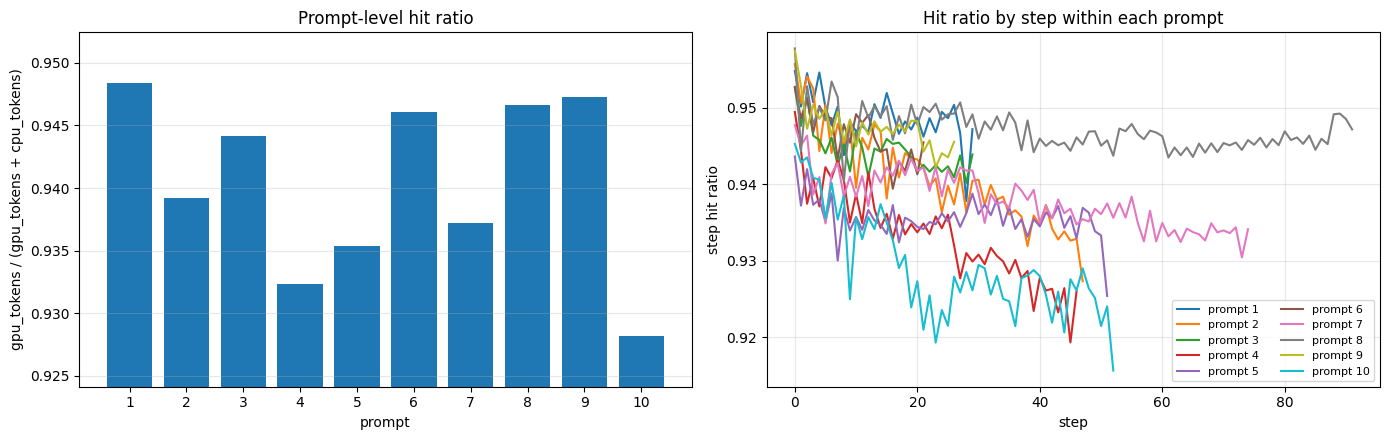

In [14]:
# Hit ratio for the 10 prompts in the sample dInfer eval log
import ast
from pathlib import Path

from matplotlib import pyplot as plt

log_path = Path("out/eval_dinfer-16484590.out")

records = []
for line in log_path.read_text().splitlines():
    if line.startswith("{"):
        record = ast.literal_eval(line)
        if "offload_stats" in record:
            records.append(record)

# A new prompt starts whenever the block index drops back to an earlier block.
prompt_records = []
current_prompt = []
previous_block = None

for record in records:
    block = record["block"]
    if previous_block is not None and block < previous_block:
        prompt_records.append(current_prompt)
        current_prompt = []
    current_prompt.append(record)
    previous_block = block

if current_prompt:
    prompt_records.append(current_prompt)

assert len(prompt_records) == 10, f"expected 10 prompts, found {len(prompt_records)}"

prompt_ids = list(range(1, len(prompt_records) + 1))
prompt_steps = []
prompt_hit_ratios = []

for prompt in prompt_records:
    total_gpu_tokens = sum(step["offload_stats"]["gpu_tokens"] for step in prompt)
    total_cpu_tokens = sum(step["offload_stats"]["cpu_tokens"] for step in prompt)
    prompt_steps.append(len(prompt))
    prompt_hit_ratios.append(total_gpu_tokens / (total_gpu_tokens + total_cpu_tokens))

ymin = min(prompt_hit_ratios)
ymax = max(prompt_hit_ratios)
padding = max((ymax - ymin) * 0.2, 0.001)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].bar(prompt_ids, prompt_hit_ratios, color="tab:blue")
axes[0].set_xticks(prompt_ids)
axes[0].set_xlabel("prompt")
axes[0].set_ylabel("gpu_tokens / (gpu_tokens + cpu_tokens)")
axes[0].set_title("Prompt-level hit ratio")
axes[0].set_ylim(ymin - padding, min(1.0, ymax + padding))
axes[0].grid(axis="y", alpha=0.3)

for prompt_id, prompt in enumerate(prompt_records, start=1):
    steps = list(range(len(prompt)))
    hit_ratios = [
        step["offload_stats"]["gpu_tokens"]
        / (step["offload_stats"]["gpu_tokens"] + step["offload_stats"]["cpu_tokens"])
        for step in prompt
    ]
    axes[1].plot(steps, hit_ratios, linewidth=1.5, label=f"prompt {prompt_id}")

axes[1].set_xlabel("step")
axes[1].set_ylabel("step hit ratio")
axes[1].set_title("Hit ratio by step within each prompt")
axes[1].grid(alpha=0.3)
axes[1].legend(ncol=2, fontsize=8)

plt.tight_layout()

list(zip(prompt_ids, prompt_steps, prompt_hit_ratios))


In [9]:
import ast
experts_on_gpu = 128 * 18
with open("out/job-15832819.out", "r") as f:
    for line in f:
        if line.startswith("{"):
            record = ast.literal_eval(line)
            if "offload_stats" in record:
                experts_on_gpu += record["offload_stats"]["promotions"] - record["offload_stats"]["demotions"]
                if (experts_on_gpu > 128 * 18):
                    print("Exceeded GPU capacity!")
                # print(experts_on_gpu)

[('jump step1', 28, 0.9499835171846642),
 ('jump step2', 30, 0.9483931182121972),
 ('jump step3', 28, 0.9480897657667876),
 ('jump step4', 29, 0.9478776701167144),
 ('jump step5', 28, 0.9474894622920939)]

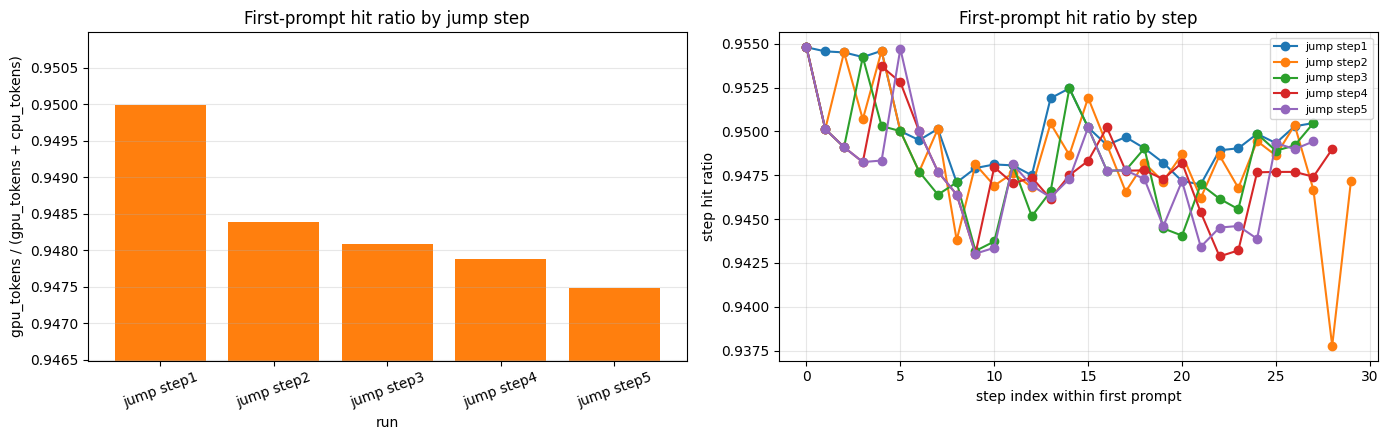

In [15]:
# Compare hit ratio for the first prompt across jump-step runs
import ast
from pathlib import Path

from matplotlib import pyplot as plt

log_paths = {
    "jump step1": Path("out/eval_dinfer-16484569.out"),
    "jump step2": Path("out/eval_dinfer-16484590.out"),
    "jump step3": Path("out/eval_dinfer-16516407.out"),
    "jump step4": Path("out/eval_dinfer-16516409.out"),
    "jump step5": Path("out/eval_dinfer-16516410.out"),
}

def load_prompt_records(path):
    records = []
    for line in path.read_text().splitlines():
        if line.startswith("{"):
            record = ast.literal_eval(line)
            if "offload_stats" in record:
                records.append(record)

    prompt_records = []
    current_prompt = []
    previous_block = None

    for record in records:
        block = record["block"]
        if previous_block is not None and block < previous_block:
            prompt_records.append(current_prompt)
            current_prompt = []
        current_prompt.append(record)
        previous_block = block

    if current_prompt:
        prompt_records.append(current_prompt)

    return prompt_records

first_prompt_results = {}
for label, path in log_paths.items():
    prompt_records = load_prompt_records(path)
    assert len(prompt_records) == 10, f"expected 10 prompts in {path}, found {len(prompt_records)}"

    first_prompt = prompt_records[0]
    total_gpu_tokens = sum(step["offload_stats"]["gpu_tokens"] for step in first_prompt)
    total_cpu_tokens = sum(step["offload_stats"]["cpu_tokens"] for step in first_prompt)
    step_hit_ratios = [
        step["offload_stats"]["gpu_tokens"]
        / (step["offload_stats"]["gpu_tokens"] + step["offload_stats"]["cpu_tokens"])
        for step in first_prompt
    ]

    first_prompt_results[label] = {
        "num_steps": len(first_prompt),
        "prompt_hit_ratio": total_gpu_tokens / (total_gpu_tokens + total_cpu_tokens),
        "step_hit_ratios": step_hit_ratios,
    }

labels = list(log_paths)
prompt_hit_ratios = [first_prompt_results[label]["prompt_hit_ratio"] for label in labels]
ymin = min(prompt_hit_ratios)
ymax = max(prompt_hit_ratios)
padding = max((ymax - ymin) * 0.2, 0.001)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].bar(labels, prompt_hit_ratios, color="tab:orange")
axes[0].set_xlabel("run")
axes[0].set_ylabel("gpu_tokens / (gpu_tokens + cpu_tokens)")
axes[0].set_title("First-prompt hit ratio by jump step")
axes[0].set_ylim(ymin - padding, min(1.0, ymax + padding))
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(axis="y", alpha=0.3)

# Step index is the sequential record order within the first prompt.
for label in labels:
    step_hit_ratios = first_prompt_results[label]["step_hit_ratios"]
    step_indices = list(range(len(step_hit_ratios)))
    axes[1].plot(step_indices, step_hit_ratios, marker="o", linewidth=1.5, label=label)

axes[1].set_xlabel("step index within first prompt")
axes[1].set_ylabel("step hit ratio")
axes[1].set_title("First-prompt hit ratio by step")
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)

plt.tight_layout()

[(label, first_prompt_results[label]["num_steps"], first_prompt_results[label]["prompt_hit_ratio"]) for label in labels]


[('jump step1', 78, 0.9468424807185489),
 ('jump step2', 92, 0.9466468812956434),
 ('jump step3', 92, 0.9450329433976954),
 ('jump step4', 100, 0.945495343030534),
 ('jump step5', 89, 0.945106400885846)]

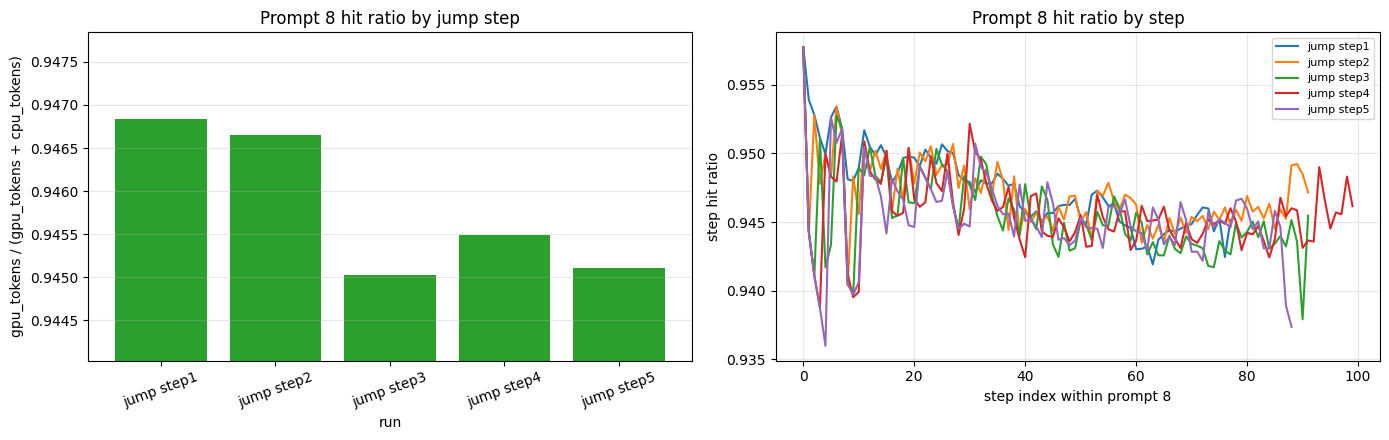

In [17]:
# Compare hit ratio for the 8th prompt across jump-step runs
import ast
from pathlib import Path

from matplotlib import pyplot as plt

log_paths = {
    "jump step1": Path("out/eval_dinfer-16484569.out"),
    "jump step2": Path("out/eval_dinfer-16484590.out"),
    "jump step3": Path("out/eval_dinfer-16516407.out"),
    "jump step4": Path("out/eval_dinfer-16516409.out"),
    "jump step5": Path("out/eval_dinfer-16516410.out"),
}

prompt_index = 7
prompt_number = prompt_index + 1

def load_prompt_records(path):
    records = []
    for line in path.read_text().splitlines():
        if line.startswith("{"):
            record = ast.literal_eval(line)
            if "offload_stats" in record:
                records.append(record)

    prompt_records = []
    current_prompt = []
    previous_block = None

    for record in records:
        block = record["block"]
        if previous_block is not None and block < previous_block:
            prompt_records.append(current_prompt)
            current_prompt = []
        current_prompt.append(record)
        previous_block = block

    if current_prompt:
        prompt_records.append(current_prompt)

    return prompt_records

prompt_results = {}
for label, path in log_paths.items():
    prompt_records = load_prompt_records(path)
    assert len(prompt_records) == 10, f"expected 10 prompts in {path}, found {len(prompt_records)}"

    prompt = prompt_records[prompt_index]
    total_gpu_tokens = sum(step["offload_stats"]["gpu_tokens"] for step in prompt)
    total_cpu_tokens = sum(step["offload_stats"]["cpu_tokens"] for step in prompt)
    step_hit_ratios = [
        step["offload_stats"]["gpu_tokens"]
        / (step["offload_stats"]["gpu_tokens"] + step["offload_stats"]["cpu_tokens"])
        for step in prompt
    ]

    prompt_results[label] = {
        "num_steps": len(prompt),
        "prompt_hit_ratio": total_gpu_tokens / (total_gpu_tokens + total_cpu_tokens),
        "step_hit_ratios": step_hit_ratios,
    }

labels = list(log_paths)
prompt_hit_ratios = [prompt_results[label]["prompt_hit_ratio"] for label in labels]
ymin = min(prompt_hit_ratios)
ymax = max(prompt_hit_ratios)
padding = max((ymax - ymin) * 0.2, 0.001)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].bar(labels, prompt_hit_ratios, color="tab:green")
axes[0].set_xlabel("run")
axes[0].set_ylabel("gpu_tokens / (gpu_tokens + cpu_tokens)")
axes[0].set_title(f"Prompt {prompt_number} hit ratio by jump step")
axes[0].set_ylim(ymin - padding, min(1.0, ymax + padding))
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(axis="y", alpha=0.3)

# Step index is the sequential record order within the selected prompt.
for label in labels:
    step_hit_ratios = prompt_results[label]["step_hit_ratios"]
    step_indices = list(range(len(step_hit_ratios)))
    axes[1].plot(step_indices, step_hit_ratios, linewidth=1.5, label=label)

axes[1].set_xlabel(f"step index within prompt {prompt_number}")
axes[1].set_ylabel("step hit ratio")
axes[1].set_title(f"Prompt {prompt_number} hit ratio by step")
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)

plt.tight_layout()

[(label, prompt_results[label]["num_steps"], prompt_results[label]["prompt_hit_ratio"]) for label in labels]


[('jump step2', 78, -0.0008995331948262883, 0.009313703094541936),
 ('jump step3', 78, -0.0013565233532724212, 0.0062772046119085045),
 ('jump step4', 78, -0.0027626417875182318, 0.006730763639686388),
 ('jump step5', 78, -0.00396816722334975, 0.012624679151714502)]

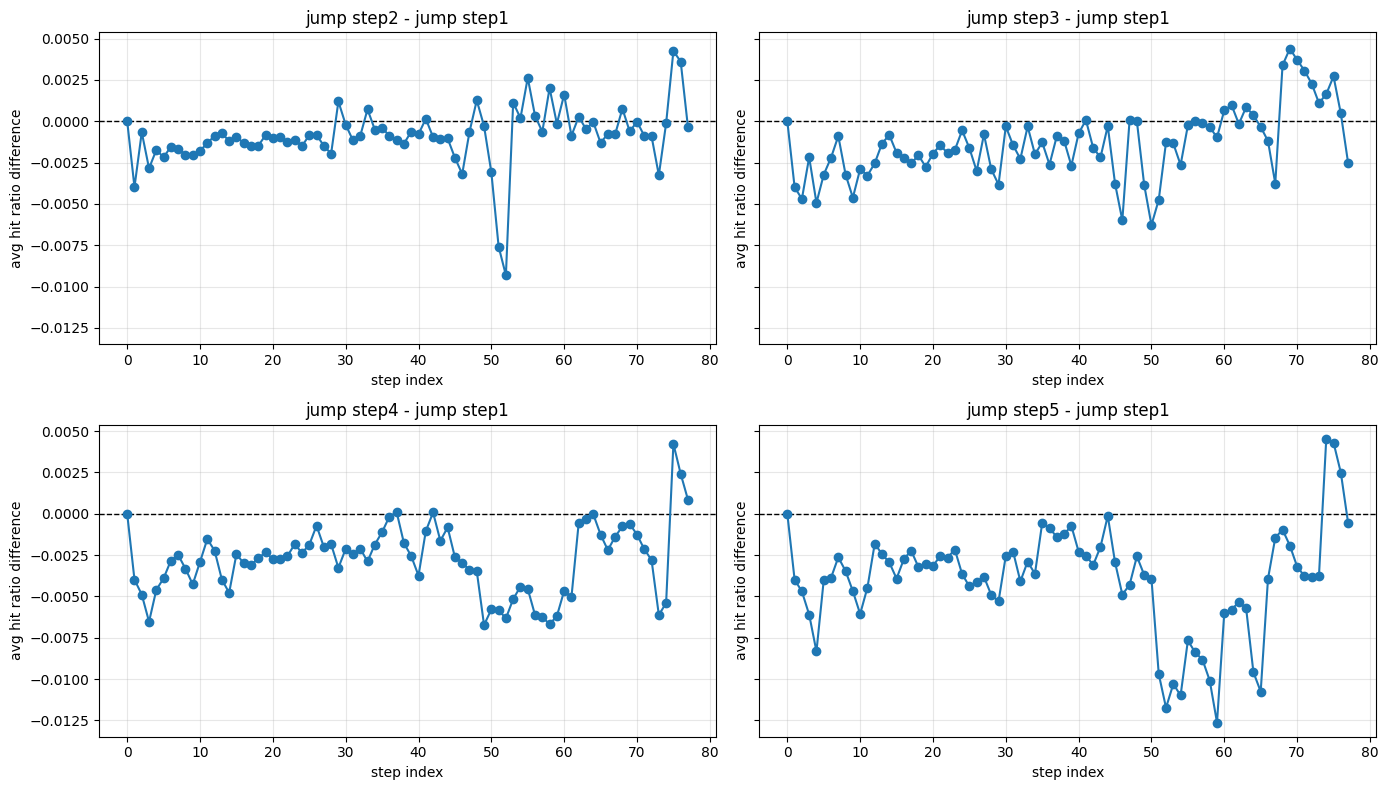

In [18]:
# Average hit ratio across all 10 prompts, compared against jump step1
import ast
from pathlib import Path

from matplotlib import pyplot as plt

log_paths = {
    "jump step1": Path("out/eval_dinfer-16484569.out"),
    "jump step2": Path("out/eval_dinfer-16484590.out"),
    "jump step3": Path("out/eval_dinfer-16516407.out"),
    "jump step4": Path("out/eval_dinfer-16516409.out"),
    "jump step5": Path("out/eval_dinfer-16516410.out"),
}

def load_prompt_records(path):
    records = []
    for line in path.read_text().splitlines():
        if line.startswith("{"):
            record = ast.literal_eval(line)
            if "offload_stats" in record:
                records.append(record)

    prompt_records = []
    current_prompt = []
    previous_block = None

    for record in records:
        block = record["block"]
        if previous_block is not None and block < previous_block:
            prompt_records.append(current_prompt)
            current_prompt = []
        current_prompt.append(record)
        previous_block = block

    if current_prompt:
        prompt_records.append(current_prompt)

    return prompt_records

def average_hit_ratio_by_step(prompt_records):
    max_steps = max(len(prompt) for prompt in prompt_records)
    avg_hit_ratios = []
    counts = []

    for step_index in range(max_steps):
        step_values = []
        for prompt in prompt_records:
            if step_index < len(prompt):
                offload_stats = prompt[step_index]["offload_stats"]
                step_values.append(
                    offload_stats["gpu_tokens"]
                    / (offload_stats["gpu_tokens"] + offload_stats["cpu_tokens"])
                )
        avg_hit_ratios.append(sum(step_values) / len(step_values))
        counts.append(len(step_values))

    return avg_hit_ratios, counts

avg_results = {}
for label, path in log_paths.items():
    prompt_records = load_prompt_records(path)
    assert len(prompt_records) == 10, f"expected 10 prompts in {path}, found {len(prompt_records)}"
    avg_hit_ratios, counts = average_hit_ratio_by_step(prompt_records)
    avg_results[label] = {
        "avg_hit_ratios": avg_hit_ratios,
        "counts": counts,
    }

baseline_label = "jump step1"
comparison_labels = [label for label in log_paths if label != baseline_label]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)
axes = axes.flatten()

summary = []
for axis, label in zip(axes, comparison_labels):
    baseline_avg = avg_results[baseline_label]["avg_hit_ratios"]
    current_avg = avg_results[label]["avg_hit_ratios"]
    comparison_steps = min(len(baseline_avg), len(current_avg))
    step_indices = list(range(comparison_steps))
    diff = [current_avg[i] - baseline_avg[i] for i in range(comparison_steps)]

    axis.axhline(0.0, color="black", linewidth=1, linestyle="--")
    axis.plot(step_indices, diff, marker="o", linewidth=1.5)
    axis.set_title(f"{label} - {baseline_label}")
    axis.set_xlabel("step index")
    axis.set_ylabel("avg hit ratio difference")
    axis.grid(alpha=0.3)

    summary.append((label, comparison_steps, sum(diff) / len(diff), max(abs(value) for value in diff)))

plt.tight_layout()

summary
